In [3]:
import pandas as pd
# Creating initial Data Frame
df = pd.read_csv("PitchingData.csv", sep = ",")

# Eliminating String Features to be able to run Correlation Analysis
clean_df = df.drop(['Name', 'ID'], axis=1)

## Split the Data into Train and Test sets

In [4]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(clean_df,
test_size=0.2, random_state=123)
print(len(train_set), len(test_set))

from sklearn.linear_model import LinearRegression
reg = LinearRegression()

X = train_set[['Last Year Yahoo Fantasy Pts']]
y = train_set['Current Year']
reg.fit(X, y)

336 84


LinearRegression()

## Create Model
## Independent Variable - Last Year Yahoo Fantasy Pts
## Dependent Variable - Current Year Yahoo Fantasy Pts

In [5]:
print("The bias is " , reg.intercept_)
print("The feature coefficients are ", reg.coef_)
print("The score for the training set is", reg.score(X,y))

# Check the performance on the test set
X_test = test_set[['Last Year Yahoo Fantasy Pts']]
y_test = test_set['Current Year']
print("The score for the test set is", reg.score(X_test,y_test))

The bias is  162.9853582599067
The feature coefficients are  [0.45515984]
The score for the training set is 0.2092713039379257
The score for the test set is 0.23218248532472097


## Checking for Correlations

Text(0.5, 1.0, 'Prior Year Statistics Correlating with Current Year Yahoo Fantasy Pts')

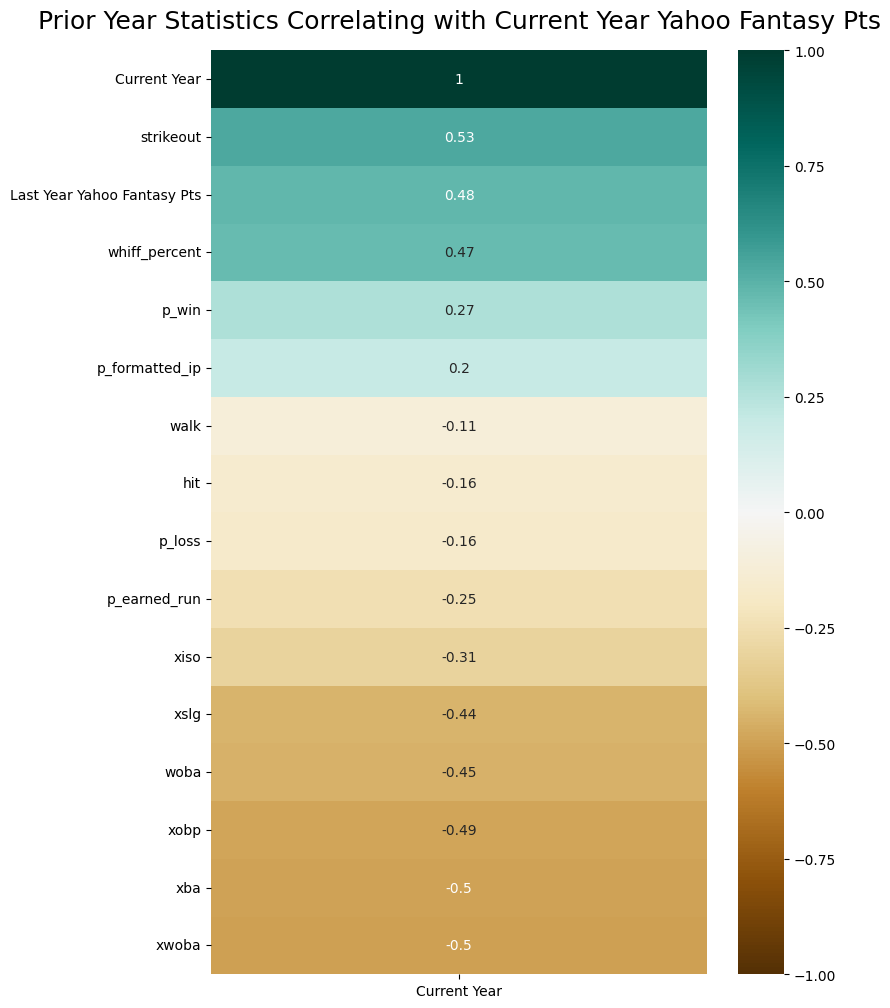

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting Correlation HeatMap
plt.figure(figsize=(8, 12))
heatmap = sns.heatmap(clean_df.corr()[['Current Year']].sort_values(by='Current Year', ascending=False), vmin=-1, vmax=1, 
                      annot=True, cmap='BrBG')
heatmap.set_title('Prior Year Statistics Correlating with Current Year Yahoo Fantasy Pts', fontdict={'fontsize':18}, pad=16)

## Creating Model Version 2
## Multi-Feature Model

In [9]:
X = train_set[['strikeout','xwoba', 'whiff_percent', 'xba']]
y = train_set['Current Year']
reg.fit(X, y)

print("The bias is " , reg.intercept_)
print("The feature coefficients are ", reg.coef_)
print("The score for the training set is", reg.score(X,y))

# Check the performance on the test set
X_test = test_set[['strikeout', 'xwoba', 'whiff_percent', 'xba']]
y_test = test_set['Current Year']
print("The score for the test set is", reg.score(X_test,y_test))

The bias is  419.92929244343287
The feature coefficients are  [ 7.72892125e-01 -1.23145394e+03  3.80259403e+00  2.27155112e+02]
The score for the training set is 0.2892434326742227
The score for the test set is 0.3850655887725464


## Create a Model using a Decision Tree

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

In [15]:
import pandas as pd

data = pd.read_csv('PitchingData.csv')

# Separate features (X) and target variable (y)
X = data.drop(['Current Year', 'Name', 'ID'], axis=1)
y = data['Current Year']

# Split data into training and testing sets (test_size=0.2 for 20% test data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Create the decision tree regression model
model = DecisionTreeRegressor(max_depth=6)

# Train the model on the training data
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6)

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score

# Make predictions on testing data
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Mean Squared Error: 15324.983038793804
R-squared: 0.022211011100174094


#### Decision Tree Results
| Depth | MSE   | R2    |
| ----- | ----- | ----- |
| 5     | 13918 | .1119 |
| 4     | 13810 | .1188 |
| 3     | 12992 | .1710 |
| 2     | 14612 | .0676 |
| 1     | 15004 | .0426 |





## LASSO Regression

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

# Create the LASSO model with alpha (regularization parameter)
model = Lasso(alpha=10)  # Adjust alpha as needed

# Train the model on the training data
model.fit(X_train, y_train)

Lasso(alpha=10)

In [41]:
# Make predictions on testing data
y_pred = model.predict(X_test)

# Evaluate model performance (e.g., using mean squared error)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Mean Squared Error: 12394.04560404475
R-squared: 0.2092153518943738


#### Lasso Alpha Analysis
| Alpha | MSE   | R2    |
| ----- | ----- | ----- |
| .001  | 12114 | .2270 |
| .01   | 12241 | .2189 |
| .1    | 12406 | .2084 |
| 1     | 12497 | .2026 |
| 10    | 12394 | .2092 |
